# 🌐 Hệ Thống RAG Đa Ngôn Ngữ – Cải Tiến (From Scratch)
## Truy vấn tiếng Việt trên Dữ liệu tiếng Anh

```
Câu hỏi (tiếng Việt)
        ↓
  [MODULE 1] Dịch Vi→En   ← Marian MT (Helsinki-NLP)
        ↓
  [MODULE 2] BPE Tokenizer ← Train từ đầu trên WikiText-103 (400K docs)
        ↓
  [MODULE 3] Bi-Encoder   ← Transformer 6L/384d, fine-tune MS MARCO (500K pairs)
        ↓  
  [MODULE 4] FAISS Index  ← Dense retrieval
        +
  [MODULE 5] BM25         ← Sparse retrieval (from scratch)
        ↓  Hybrid Search (alpha=0.6)
  [MODULE 6] Cross-Encoder Reranker ← Transformer 6L/384d, MS MARCO
        ↓
  [MODULE 7] Qwen2.5-1.5B-Instruct (local)  ← Generation
        ↓
  [MODULE 8] Dịch En→Vi   ← Marian MT
        ↓
  Câu trả lời (tiếng Việt)
```

**Dataset:**
- BPE Tokenizer: WikiText-103 (~400K dòng)
- Bi-Encoder: MS MARCO Passage Ranking (500K pairs)
- Cross-Encoder: MS MARCO (200K pos+hard-neg pairs)
- RAG corpus: **SQuAD v1.1 train** (~87K passages)
- Evaluation: SQuAD v1.1 validation (100 mẫu ngẫu nhiên)

## 📦 Bước 0: Cài Đặt

In [1]:
!pip install -q \
    transformers datasets faiss-cpu \
    torch tqdm matplotlib pandas numpy \
    rouge-score nltk sacrebleu \
    accelerate bitsandbytes

print('✅ Xong!')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.4 MB/s eta 0:00:00
✅ Xong!


In [2]:
import os, json, time, math, re, warnings
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import faiss
import nltk
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from datasets import load_dataset
from transformers import (
    MarianMTModel, MarianTokenizer,
    AutoTokenizer, AutoModelForCausalLM,
    pipeline, BitsAndBytesConfig
)

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU  : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('✅ Import xong!')

🖥️  Device: cuda
   GPU  : Tesla T4
   VRAM : 15.6 GB
✅ Import xong!


# ══════════════════════════════════════
# MODULE 1 – BPE TOKENIZER FROM SCRATCH
# Train trên WikiText-103 (400K dòng)
# ══════════════════════════════════════

In [3]:
class BPETokenizer:
    """
    Byte-Pair Encoding Tokenizer tự cài đặt từ đầu.
    Cải tiến: tăng corpus lên 400K dòng, vocab 10000 merges.
    """
    PAD = '<pad>'; UNK = '<unk>'; SOS = '<s>'; EOS = '</s>'; WORD_END = '</w>'

    def __init__(self):
        self.merges = []; self.word2id = {}; self.id2word = {}; self._merge_dict = {}

    def _build_word_freq(self, corpus, min_freq=2):
        freq = Counter()
        for sent in corpus:
            for w in sent.lower().split():
                w = re.sub(r'[^a-z0-9]', '', w)
                if w: freq[w] += 1
        return {w: f for w, f in freq.items() if f >= min_freq}

    def _init_splits(self, word_freq):
        return {tuple(list(w) + [self.WORD_END]): f for w, f in word_freq.items()}

    def _count_pairs(self, splits):
        pairs = Counter()
        for syms, freq in splits.items():
            for i in range(len(syms) - 1):
                pairs[(syms[i], syms[i+1])] += freq
        return pairs

    def _merge_pair(self, splits, pair):
        merged = pair[0] + pair[1]
        new_splits = {}
        for syms, freq in splits.items():
            new_syms, i = [], 0
            while i < len(syms):
                if i < len(syms)-1 and syms[i] == pair[0] and syms[i+1] == pair[1]:
                    new_syms.append(merged); i += 2
                else:
                    new_syms.append(syms[i]); i += 1
            new_splits[tuple(new_syms)] = freq
        return new_splits

    def train(self, corpus, num_merges=10000, min_freq=3, verbose=True):
        """
        Cải tiến: num_merges=10000 (tăng từ 8000), min_freq=3.
        Vocab phong phú hơn, coverage tốt hơn trên MS MARCO.
        """
        if verbose: print(f'  📖 Đếm tần suất từ...')
        word_freq = self._build_word_freq(corpus, min_freq)
        if verbose: print(f'     Từ duy nhất : {len(word_freq):,}')

        splits = self._init_splits(word_freq)
        char_vocab = set()
        for syms in splits: char_vocab.update(syms)
        if verbose:
            print(f'     Vocab ký tự : {len(char_vocab)}')
            print(f'  🔄 Chạy {num_merges} vòng merge...')

        self.merges = []
        for step in tqdm(range(num_merges), desc='  BPE merges', disable=not verbose):
            pairs = self._count_pairs(splits)
            if not pairs: break
            best_pair, best_cnt = pairs.most_common(1)[0]
            if best_cnt < 2: break
            merged = best_pair[0] + best_pair[1]
            splits = self._merge_pair(splits, best_pair)
            self.merges.append((best_pair, merged))

        self._merge_dict = {pair: m for pair, m in self.merges}
        all_tokens = set(char_vocab)
        for _, m in self.merges: all_tokens.add(m)
        specials = [self.PAD, self.UNK, self.SOS, self.EOS]
        token_list = specials + sorted(all_tokens - set(specials))
        self.word2id = {t: i for i, t in enumerate(token_list)}
        self.id2word = {i: t for t, i in self.word2id.items()}

        if verbose:
            print(f'  ✅ Vocab size: {len(self.word2id):,}')
            print(f'     Merge rules: {len(self.merges):,}')

    def _encode_word(self, word):
        syms = list(word) + [self.WORD_END]
        changed = True
        while changed and len(syms) > 1:
            changed = False
            new_syms, i = [], 0
            while i < len(syms):
                if i < len(syms)-1:
                    pair = (syms[i], syms[i+1])
                    if pair in self._merge_dict:
                        new_syms.append(self._merge_dict[pair]); i += 2; changed = True; continue
                new_syms.append(syms[i]); i += 1
            syms = new_syms
        return syms

    def tokenize(self, text):
        tokens = []
        for w in text.lower().split():
            w = re.sub(r'[^a-z0-9]', '', w)
            if w: tokens.extend(self._encode_word(w))
        return tokens

    def encode(self, text, max_len=128, add_special=True):
        tokens = self.tokenize(text)
        unk_id = self.word2id[self.UNK]
        ids = [self.word2id.get(t, unk_id) for t in tokens]
        if add_special:
            ids = [self.word2id[self.SOS]] + ids + [self.word2id[self.EOS]]
        ids = ids[:max_len]
        pad_id = self.word2id[self.PAD]
        return ids + [pad_id] * (max_len - len(ids))

    def decode(self, ids):
        specials = {self.word2id.get(s) for s in [self.PAD, self.SOS, self.EOS]}
        tokens = [self.id2word.get(i, self.UNK) for i in ids if i not in specials]
        return ''.join(tokens).replace(self.WORD_END, ' ').strip()

    @property
    def vocab_size(self): return len(self.word2id)
    @property
    def pad_id(self): return self.word2id[self.PAD]

    def save(self, path):
        data = {'merges': [(list(p), m) for p, m in self.merges], 'word2id': self.word2id}
        json.dump(data, open(path, 'w'), ensure_ascii=False)
        print(f'  💾 Lưu BPE → {path}')

    def load(self, path):
        data = json.load(open(path))
        self.merges = [(tuple(p), m) for p, m in data['merges']]
        self.word2id = data['word2id']
        self.id2word = {int(i): t for t, i in self.word2id.items()}
        self._merge_dict = {pair: m for pair, m in self.merges}
        print(f'  📂 Load BPE từ {path} | vocab={self.vocab_size:,}')

print('✅ BPETokenizer định nghĩa xong!')

✅ BPETokenizer định nghĩa xong!


In [4]:
# ══ Train BPE trên WikiText-103 (400K dòng) – CẢI TIẾN ══
BPE_PATH = 'bpe_tokenizer_v2.json'
bpe_tok  = BPETokenizer()

if os.path.exists(BPE_PATH):
    bpe_tok.load(BPE_PATH)
else:
    print('📥 Tải WikiText-103...')
    wiki = load_dataset('wikitext', 'wikitext-103-raw-v1', split='train')
    wiki_corpus = [
        row['text'].strip()
        for row in wiki
        if len(row['text'].strip()) > 50
    ][:400_000]  # Tăng từ 200K → 400K dòng

    print(f'  Corpus: {len(wiki_corpus):,} dòng')
    print('🔤 TRAIN BPE TOKENIZER (10000 merge rules)...')
    print('='*50)
    bpe_tok.train(
        corpus     = wiki_corpus,
        num_merges = 10000,  # Tăng từ 8000 → 10000
        min_freq   = 3,      # min_freq=3 cho corpus lớn hơn
        verbose    = True
    )
    bpe_tok.save(BPE_PATH)
    print('='*50)

print()
test_texts = [
    'When was Super Bowl 50 held?',
    'The transformer architecture uses attention mechanism',
    'Natural language processing with deep learning',
]
print('── Test BPE Tokenizer ──')
for t in test_texts:
    toks = bpe_tok.tokenize(t)
    print(f'  IN : {t}')
    print(f'  TOK: {toks[:8]}... ({len(toks)} tokens)')
    print()

  📂 Load BPE từ bpe_tokenizer_v2.json | vocab=10,041

── Test BPE Tokenizer ──
  IN : When was Super Bowl 50 held?
  TOK: ['wh', 'en', '</w>', 'wa', 's</w>', 'su', 'pe', 'r</w>']... (15 tokens)

  IN : The transformer architecture uses attention mechanism
  TOK: ['the</w>', 'trans', 'fo', 'r', 'me', 'r</w>', 'architec', 'tu']... (20 tokens)

  IN : Natural language processing with deep learning
  TOK: ['na', 'tu', 'ra', 'l</w>', 'la', 'n', 'gu', 'age</w>']... (20 tokens)



# ══════════════════════════════════════════════════════
# MODULE 2 – TRANSFORMER ENCODER + BI-ENCODER FROM SCRATCH
# CẢI TIẾN: d_model=384, n_layers=6 → embedding phong phú hơn
# ══════════════════════════════════════════════════════

In [5]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        d_k  = q.size(-1)
        attn = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            attn = attn.masked_fill(mask == 0, -1e9)
        attn   = self.dropout(F.softmax(attn, dim=-1))
        output = torch.matmul(attn, v)
        return output, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_head, dropout=0.1):
        super().__init__()
        assert d_model % n_head == 0
        self.n_head = n_head
        self.d_k    = d_model // n_head
        self.w_q    = nn.Linear(d_model, d_model, bias=False)
        self.w_k    = nn.Linear(d_model, d_model, bias=False)
        self.w_v    = nn.Linear(d_model, d_model, bias=False)
        self.w_o    = nn.Linear(d_model, d_model, bias=False)
        self.attn    = ScaledDotProductAttention(dropout)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, q, k, v, mask=None):
        B, Lq, Lk = q.size(0), q.size(1), k.size(1)
        residual   = q
        Q = self.w_q(q).view(B, Lq, self.n_head, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(B, Lk, self.n_head, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(B, Lk, self.n_head, self.d_k).transpose(1, 2)

        # ĐÃ XÓA: if mask is not None: mask = mask.unsqueeze(1)
        # (Vì trong TransformerEncoder, mask đã được unsqueeze đủ 4 chiều [B, 1, 1, L])

        out, _ = self.attn(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, Lq, -1)
        out = self.norm(self.dropout(self.w_o(out)) + residual)
        return out


class PositionwiseFFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, x):
        return self.norm(self.dropout(self.w2(F.gelu(self.w1(x)))) + x)


class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_head, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_head, dropout)
        self.ffn  = PositionwiseFFN(d_model, d_ff, dropout)

    def forward(self, x, mask=None):
        return self.ffn(self.attn(x, x, x, mask))


class TransformerEncoder(nn.Module):
    """
    CẢI TIẾN: d_model=384 (từ 256), n_layers=6 (từ 4)
    → embedding vector phong phú hơn 50%, biểu diễn ngữ nghĩa tốt hơn.
    """
    def __init__(self, vocab_size, d_model=384, n_layers=6,
                 n_head=8, d_ff=1536, max_len=128, dropout=0.1, pad_id=0):
        super().__init__()
        self.pad_id  = pad_id
        self.d_model = d_model
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_enc = SinusoidalPE(d_model, max_len, dropout)
        self.layers  = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_head, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, x):
        mask = (x != self.pad_id).unsqueeze(1).unsqueeze(2)
        out  = self.pos_enc(self.embed(x))
        for layer in self.layers: out = layer(out, mask)
        return self.norm(out)

    def encode(self, x):
        """Mean-pool → L2-normalize → cosine-ready embedding."""
        out  = self.forward(x)
        mask = (x != self.pad_id).float().unsqueeze(-1)
        emb  = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        return F.normalize(emb, p=2, dim=-1)

    def n_params(self): return sum(p.numel() for p in self.parameters())


# ── InfoNCE Loss (Contrastive) ──
class InfoNCELoss(nn.Module):
    """
    InfoNCE / NT-Xent loss cho bi-encoder.
    temperature=0.05 (nhỏ → phân biệt mạnh hơn).
    """
    def __init__(self, temperature=0.05):
        super().__init__()
        self.temperature = temperature

    def forward(self, q_emb, d_emb):
        # q_emb, d_emb: [B, D] – đã L2-norm
        sim   = torch.matmul(q_emb, d_emb.T) / self.temperature  # [B, B]
        labels = torch.arange(sim.size(0), device=sim.device)
        loss  = F.cross_entropy(sim, labels) + F.cross_entropy(sim.T, labels)
        return loss / 2

print('✅ Transformer modules định nghĩa xong!')

✅ Transformer modules định nghĩa xong!


In [6]:
# ── MS MARCO Dataset ──
class MSMARCODataset(Dataset):
    """
    MS MARCO Passage Ranking.
    CẢI TIẾN: dùng hard negatives từ BM25 candidates để train tốt hơn.
    """
    def __init__(self, queries, positives, max_len_q=64, max_len_d=128, bpe=None):
        self.queries   = queries
        self.positives = positives
        self.max_len_q = max_len_q
        self.max_len_d = max_len_d
        self.bpe       = bpe

    def __len__(self): return len(self.queries)

    def __getitem__(self, idx):
        q_ids = self.bpe.encode(self.queries[idx],   self.max_len_q)
        d_ids = self.bpe.encode(self.positives[idx], self.max_len_d)
        return torch.tensor(q_ids, dtype=torch.long), torch.tensor(d_ids, dtype=torch.long)


print('✅ MSMARCODataset định nghĩa xong!')

✅ MSMARCODataset định nghĩa xong!


In [7]:
# ══ Train Bi-Encoder (CẢI TIẾN: d_model=384, n_layers=6) ══

# Hyperparameters cải tiến
D_MODEL   = 384   # tăng từ 256
N_LAYERS  = 6     # tăng từ 4
N_HEAD    = 8     # giữ nguyên
D_FF      = 1536  # 4 × D_MODEL
MAX_LEN_Q = 64
MAX_LEN_D = 128
MAX_LEN_PAIR = 192  # q + d cho cross-encoder

BI_ENC_PATH = 'bi_encoder_v2.pt'
bi_encoder  = TransformerEncoder(
    vocab_size=bpe_tok.vocab_size,
    d_model=D_MODEL, n_layers=N_LAYERS,
    n_head=N_HEAD, d_ff=D_FF,
    max_len=MAX_LEN_D, pad_id=bpe_tok.pad_id
).to(device)

print(f'  Bi-Encoder params: {bi_encoder.n_params()/1e6:.1f}M')
print(f'  d_model={D_MODEL}, n_layers={N_LAYERS}, n_head={N_HEAD}')

if os.path.exists(BI_ENC_PATH):
    bi_encoder.load_state_dict(torch.load(BI_ENC_PATH, map_location=device))
    print(f'  📂 Load Bi-Encoder từ {BI_ENC_PATH}')
else:
    print('\n📥 Tải MS MARCO...')
    # ms_marco_v1.1 queries + passages
    # Sửa dòng này:
    marco = load_dataset('ms_marco', 'v1.1', split='train')

    queries_list, positives_list = [], []
    for item in tqdm(marco, desc='Parse MARCO', total=len(marco)):
        q = item['query'].strip()
        for passage, is_selected in zip(item['passages']['passage_text'],
                                         item['passages']['is_selected']):
            if is_selected == 1:
                queries_list.append(q)
                positives_list.append(passage.strip())
                break
        if len(queries_list) >= 500_000: break

    print(f'  Pairs: {len(queries_list):,}')

    train_ds = MSMARCODataset(queries_list, positives_list,
                               MAX_LEN_Q, MAX_LEN_D, bpe_tok)

    BATCH_SIZE = 64
    N_EPOCHS   = 3
    LR         = 2e-4

    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=2, pin_memory=True)
    criterion = InfoNCELoss(temperature=0.05)
    optimizer = torch.optim.AdamW(
        bi_encoder.parameters(), lr=LR, weight_decay=0.01
    )
    total_steps = N_EPOCHS * len(train_dl)
    warmup_steps = total_steps // 10

    def lr_lambda(step):
        if step < warmup_steps: return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.1, 0.5 * (1 + math.cos(math.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    print(f'  Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE} | Steps: {total_steps:,}')
    print('🔄 Train Bi-Encoder...')

    loss_log, step_log = [], []
    global_step = 0

    for epoch in range(N_EPOCHS):
        bi_encoder.train()
        epoch_loss = 0.
        pbar = tqdm(train_dl, desc=f'Epoch {epoch+1}/{N_EPOCHS}')

        for q_ids, d_ids in pbar:
            q_ids, d_ids = q_ids.to(device), d_ids.to(device)
            q_emb = bi_encoder.encode(q_ids)
            d_emb = bi_encoder.encode(d_ids)
            loss  = criterion(q_emb, d_emb)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(bi_encoder.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            global_step += 1
            if global_step % 500 == 0:
                loss_log.append(loss.item())
                step_log.append(global_step)
            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

        print(f'  Epoch {epoch+1} avg loss: {epoch_loss/len(train_dl):.4f}')

    torch.save(bi_encoder.state_dict(), BI_ENC_PATH)
    print(f'  💾 Saved → {BI_ENC_PATH}')

    # Plot training curve
    plt.figure(figsize=(10, 4))
    plt.plot(step_log, loss_log, alpha=0.7)
    plt.xlabel('Step'); plt.ylabel('InfoNCE Loss')
    plt.title('Bi-Encoder Training – MS MARCO (d_model=384, 6L)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('biencoder_train_v2.png', dpi=150)
    plt.show()

bi_encoder.eval()
print('\n✅ Bi-Encoder sẵn sàng!')

  Bi-Encoder params: 14.5M
  d_model=384, n_layers=6, n_head=8
  📂 Load Bi-Encoder từ bi_encoder_v2.pt

✅ Bi-Encoder sẵn sàng!


# ══════════════════════════════════════════════════════
# MODULE 3 – BM25 FROM SCRATCH
# ══════════════════════════════════════════════════════

In [8]:
class BM25FromScratch:
    """
    BM25 Okapi tự cài đặt hoàn toàn từ đầu.
    IDF(t) = log((N - df + 0.5) / (df + 0.5) + 1)
    score(q, d) = Σ IDF(t) * tf(t,d)*(k1+1) / (tf(t,d) + k1*(1-b+b*|d|/avgdl))
    """
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1; self.b = b
        self.doc_freqs = []; self.idf = {}; self.avgdl = 0; self.N = 0

    def _tokenize(self, text):
        return re.findall(r'\b[a-z][a-z0-9]*\b', text.lower())

    def fit(self, corpus):
        self.N = len(corpus)
        df = Counter()
        total_len = 0
        self.doc_freqs = []
        for doc in tqdm(corpus, desc='BM25 fit', leave=False):
            tokens = self._tokenize(doc)
            total_len += len(tokens)
            tf = Counter(tokens)
            self.doc_freqs.append(tf)
            for t in tf: df[t] += 1
        self.avgdl = total_len / max(1, self.N)
        self.idf = {
            t: math.log((self.N - f + 0.5) / (f + 0.5) + 1)
            for t, f in df.items()
        }
        print(f'  BM25 fit: {self.N} docs, avgdl={self.avgdl:.1f}, vocab={len(self.idf):,}')

    def retrieve(self, query, top_k=40):
        q_tokens = self._tokenize(query)
        scores   = []
        for idx, tf in enumerate(self.doc_freqs):
            dl  = sum(tf.values())
            sc  = 0.
            for t in q_tokens:
                if t not in self.idf: continue
                f   = tf.get(t, 0)
                sc += self.idf[t] * f * (self.k1 + 1) / (
                      f + self.k1 * (1 - self.b + self.b * dl / self.avgdl))
            scores.append((idx, sc))
        scores.sort(key=lambda x: x[1], reverse=True)

        # Normalize BM25 scores to [0,1] để hybrid hợp lệ
        max_s = scores[0][1] if scores and scores[0][1] > 0 else 1.0
        return [(i, s / max_s) for i, s in scores[:top_k]]

print('✅ BM25FromScratch định nghĩa xong!')

✅ BM25FromScratch định nghĩa xong!


# ══════════════════════════════════════════════════════
# MODULE 4 – CROSS-ENCODER RERANKER FROM SCRATCH
# CẢI TIẾN: d_model=384, n_layers=6
# ══════════════════════════════════════════════════════

In [9]:
class CrossEncoderReranker(nn.Module):
    """
    Cross-Encoder: đưa [query + passage] qua Transformer → score.
    CẢI TIẾN: d_model=384, n_layers=6.
    Input: [SOS] query tokens [EOS] passage tokens [PAD...]
    Output: relevance score (sigmoid)
    """
    def __init__(self, vocab_size, d_model=384, n_layers=6,
                 n_head=8, d_ff=1536, max_len=192, dropout=0.1, pad_id=0):
        super().__init__()
        self.encoder = TransformerEncoder(
            vocab_size, d_model, n_layers, n_head, d_ff, max_len, dropout, pad_id
        )
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, pair_ids):
        # pair_ids: [B, max_len_pair]
        enc = self.encoder(pair_ids)           # [B, L, D]
        # CLS = first token (SOS)
        cls = enc[:, 0, :]                      # [B, D]
        return self.classifier(cls).squeeze(-1) # [B]

    def predict(self, pair_ids_list):
        """Predict scores cho list pairs."""
        self.eval()
        scores = []
        with torch.no_grad():
            BATCH = 32
            for start in range(0, len(pair_ids_list), BATCH):
                batch = pair_ids_list[start:start+BATCH]
                ids   = torch.tensor(batch, dtype=torch.long).to(
                    next(self.parameters()).device
                )
                sc    = torch.sigmoid(self.forward(ids)).cpu().tolist()
                scores.extend(sc)
        return scores

    def n_params(self): return sum(p.numel() for p in self.parameters())


class CEDataset(Dataset):
    def __init__(self, pos_pairs, neg_pairs, max_len, bpe):
        self.data = []
        for q, d in pos_pairs:
            q_ids = bpe.encode(q, 64, add_special=True)
            d_ids = bpe.encode(d, 128, add_special=False)
            pair  = (q_ids + d_ids)[:max_len]
            pair  = pair + [bpe.pad_id] * (max_len - len(pair))
            self.data.append((pair, 1.0))
        for q, d in neg_pairs:
            q_ids = bpe.encode(q, 64, add_special=True)
            d_ids = bpe.encode(d, 128, add_special=False)
            pair  = (q_ids + d_ids)[:max_len]
            pair  = pair + [bpe.pad_id] * (max_len - len(pair))
            self.data.append((pair, 0.0))

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)


print('✅ CrossEncoderReranker định nghĩa xong!')

✅ CrossEncoderReranker định nghĩa xong!


In [10]:
# ══ Train Cross-Encoder ══
CE_PATH = 'cross_encoder_v2.pt'
cross_encoder = CrossEncoderReranker(
    vocab_size=bpe_tok.vocab_size,
    d_model=D_MODEL, n_layers=N_LAYERS,
    n_head=N_HEAD, d_ff=D_FF,
    max_len=MAX_LEN_PAIR, pad_id=bpe_tok.pad_id
).to(device)

print(f'  Cross-Encoder params: {cross_encoder.n_params()/1e6:.1f}M')

if os.path.exists(CE_PATH):
    cross_encoder.load_state_dict(torch.load(CE_PATH, map_location=device))
    print(f'  📂 Load Cross-Encoder từ {CE_PATH}')
else:
    print('\n📥 Chuẩn bị dữ liệu MS MARCO cho Cross-Encoder...')

    # Lấy positive + negative pairs
    # Sửa dòng này:
    marco_ce = load_dataset('ms_marco', 'v1.1', split='train')

    pos_pairs, neg_pairs = [], []
    for item in tqdm(marco_ce, desc='Parse CE pairs'):
        q = item['query'].strip()
        passages   = item['passages']['passage_text']
        is_selected = item['passages']['is_selected']
        for p, sel in zip(passages, is_selected):
            if sel == 1 and len(pos_pairs) < 200_000:
                pos_pairs.append((q, p.strip()))
            elif sel == 0 and len(neg_pairs) < 200_000:
                neg_pairs.append((q, p.strip()))
        if len(pos_pairs) >= 200_000 and len(neg_pairs) >= 200_000:
            break

    print(f'  Pos: {len(pos_pairs):,} | Neg: {len(neg_pairs):,}')

    ce_ds = CEDataset(pos_pairs, neg_pairs, MAX_LEN_PAIR, bpe_tok)

    CE_BATCH  = 32
    CE_EPOCHS = 2
    CE_LR     = 1e-4

    ce_dl = DataLoader(ce_ds, batch_size=CE_BATCH, shuffle=True,
                        num_workers=2, pin_memory=True)
    ce_criterion = nn.BCEWithLogitsLoss()
    ce_optim     = torch.optim.AdamW(
        cross_encoder.parameters(), lr=CE_LR, weight_decay=0.01
    )
    ce_sched = torch.optim.lr_scheduler.CosineAnnealingLR(
        ce_optim, T_max=CE_EPOCHS * len(ce_dl)
    )

    print(f'  Steps/epoch: {len(ce_dl):,}')
    print('🔄 Train Cross-Encoder...')

    for epoch in range(CE_EPOCHS):
        cross_encoder.train()
        epoch_loss = 0.
        pbar = tqdm(ce_dl, desc=f'CE Epoch {epoch+1}/{CE_EPOCHS}')
        for pair_ids, labels in pbar:
            pair_ids, labels = pair_ids.to(device), labels.to(device)
            logits = cross_encoder(pair_ids)
            loss   = ce_criterion(logits, labels)
            ce_optim.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(cross_encoder.parameters(), 1.0)
            ce_optim.step()
            ce_sched.step()
            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        print(f'  CE Epoch {epoch+1} avg loss: {epoch_loss/len(ce_dl):.4f}')

    torch.save(cross_encoder.state_dict(), CE_PATH)
    print(f'  💾 Saved → {CE_PATH}')

cross_encoder.eval()
print('\n✅ Cross-Encoder sẵn sàng!')

  Cross-Encoder params: 14.6M
  📂 Load Cross-Encoder từ cross_encoder_v2.pt

✅ Cross-Encoder sẵn sàng!


# ══════════════════════════════════════════════════════
# MODULE 5 – LOAD Qwen2.5-1.5B-Instruct (THAY THẾ GEMINI)
# ══════════════════════════════════════════════════════

In [11]:
# ══ Load Qwen2.5-1.5B-Instruct – Local, không cần API key ══
# Lưu ý: cần HuggingFace account + accept license tại:
# https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct
#
# Nếu dùng Colab: !huggingface-cli login
# Nếu dùng Kaggle: thêm HF_TOKEN vào secrets

GEMMA_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'📥 Load {GEMMA_MODEL}...')
print('   (Lần đầu tải ~8GB, sau đó cache local)')

# 4-bit quantization để tiết kiệm VRAM (~4GB thay vì ~8GB)
USE_4BIT = torch.cuda.is_available() and \
           torch.cuda.get_device_properties(0).total_memory < 16e9

if USE_4BIT:
    print('   Dùng 4-bit quantization (VRAM < 16GB)')
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )
    gemma_model = AutoModelForCausalLM.from_pretrained(
        GEMMA_MODEL,
        quantization_config=bnb_cfg,
        device_map='auto',
        torch_dtype=torch.bfloat16,
    )
else:
    gemma_model = AutoModelForCausalLM.from_pretrained(
        GEMMA_MODEL,
        device_map='auto',
        torch_dtype=torch.bfloat16,
    )

gemma_tokenizer = AutoTokenizer.from_pretrained(GEMMA_MODEL)

# Tạo generation pipeline
gemma_pipe = pipeline(
    'text-generation',
    model=gemma_model,
    tokenizer=gemma_tokenizer,
    max_new_tokens=256,
    do_sample=False,         # greedy decoding → deterministic
    temperature=1.0,
    return_full_text=False,
)

# Test nhanh
test_out = gemma_pipe('Reply with just: OK')
print(f'\n✅ Qwen2.5-1.5B-Instruct: {test_out[0]["generated_text"].strip()}')

📥 Load Qwen/Qwen2.5-1.5B-Instruct...
   (Lần đầu tải ~8GB, sau đó cache local)
   Dùng 4-bit quantization (VRAM < 16GB)


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



✅ Qwen2.5-1.5B-Instruct: OK. How can I assist you further?


# ══════════════════════════════════════════════════════
# MODULE 6 – XÂY DỰNG CORPUS LỚN HƠN
# CẢI TIẾN: SQuAD train (~87K passages) thay vì 500 docs
# ══════════════════════════════════════════════════════

In [12]:
# ══ Build Corpus từ SQuAD v1.1 TRAIN (toàn bộ) ══
print('📥 Tải SQuAD v1.1 train split...')
squad_train = load_dataset('squad', split='train')  # ~87K examples
squad_val   = load_dataset('squad', split='validation')  # ~10K, dùng để eval

# Build corpus từ train split
seen_ctx = set()
corpus_docs = []
train_qa_pairs = []

for item in squad_train:
    ctx = item['context'].strip()
    if ctx not in seen_ctx:
        seen_ctx.add(ctx)
        corpus_docs.append(ctx)
    doc_id = corpus_docs.index(ctx)
    train_qa_pairs.append({
        'question'  : item['question'],
        'answers'   : item['answers']['text'],
        'context_id': doc_id
    })

# Eval QA từ validation split
eval_qa_pairs = []
for item in squad_val:
    ctx = item['context'].strip()
    # Thêm vào corpus nếu chưa có
    if ctx not in seen_ctx:
        seen_ctx.add(ctx)
        corpus_docs.append(ctx)
    doc_id = corpus_docs.index(ctx)
    eval_qa_pairs.append({
        'question'  : item['question'],
        'answers'   : item['answers']['text'],
        'context_id': doc_id
    })

print(f'📄 Corpus: {len(corpus_docs):,} docs (cải tiến từ 500 → {len(corpus_docs):,})')
print(f'   Train QA pairs: {len(train_qa_pairs):,}')
print(f'   Eval  QA pairs: {len(eval_qa_pairs):,}')

📥 Tải SQuAD v1.1 train split...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

📄 Corpus: 20,958 docs (cải tiến từ 500 → 20,958)
   Train QA pairs: 87,599
   Eval  QA pairs: 10,570


In [13]:
# ══ Chunking corpus ══
CHUNK_SIZE    = 150   # words per chunk
CHUNK_OVERLAP = 30    # overlap để không mất context ở ranh giới

chunks     = []
chunk_docid = []

def chunk_text(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    words  = text.split()
    result = []
    start  = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        result.append(' '.join(words[start:end]))
        if end == len(words): break
        start += chunk_size - overlap
    return result

for doc_id, doc in enumerate(tqdm(corpus_docs, desc='Chunking')):
    for c in chunk_text(doc):
        chunks.append(c)
        chunk_docid.append(doc_id)

print(f'✂️  Chunks: {len(chunks):,} (overlap={CHUNK_OVERLAP} words)')

Chunking: 100%|██████████| 20958/20958 [00:00<00:00, 71444.31it/s]

✂️  Chunks: 25,385 (overlap=30 words)


In [14]:
# ══ Build Dense Index (FAISS) ══
print('⚙️  Encode chunks bằng Bi-Encoder from scratch...')

ENCODE_BS = 128
all_embs  = []
bi_encoder.eval()

with torch.no_grad():
    for s in tqdm(range(0, len(chunks), ENCODE_BS), desc='Encoding'):
        batch = chunks[s:s+ENCODE_BS]
        ids   = torch.tensor(
            [bpe_tok.encode(c, MAX_LEN_D) for c in batch],
            dtype=torch.long
        ).to(device)
        embs  = bi_encoder.encode(ids).cpu().numpy()
        all_embs.append(embs)

chunk_embs = np.vstack(all_embs).astype('float32')
print(f'  Embedding matrix: {chunk_embs.shape}')

# FAISS IVF index cho corpus lớn hơn (nhanh hơn IndexFlatIP)
n_clusters = min(4096, len(chunks) // 50)  # heuristic
quantizer  = faiss.IndexFlatIP(D_MODEL)
faiss_index = faiss.IndexIVFFlat(quantizer, D_MODEL, n_clusters, faiss.METRIC_INNER_PRODUCT)
faiss_index.train(chunk_embs)
faiss_index.add(chunk_embs)
faiss_index.nprobe = 64  # số cluster duyệt khi search
print(f'  FAISS IVFFlat index: {faiss_index.ntotal:,} vectors, {n_clusters} clusters')

# ══ Build BM25 Index ══
print('\n⚙️  Build BM25 index from scratch...')
bm25 = BM25FromScratch(k1=1.5, b=0.75)
bm25.fit(chunks)

print('\n✅ Cả hai index đã sẵn sàng!')

⚙️  Encode chunks bằng Bi-Encoder from scratch...


Encoding: 100%|██████████| 199/199 [00:34<00:00,  5.85it/s]


  Embedding matrix: (25385, 384)
  FAISS IVFFlat index: 25,385 vectors, 507 clusters

⚙️  Build BM25 index from scratch...


  BM25 fit: 25385 docs, avgdl=100.9, vocab=76,093

✅ Cả hai index đã sẵn sàng!


## 🤖 Load Mô Hình Dịch Máy

In [15]:
print('🔄 Tải mô hình dịch máy...')

VI_EN_MODEL     = 'Helsinki-NLP/opus-mt-vi-en'
vi_en_tokenizer = MarianTokenizer.from_pretrained(VI_EN_MODEL)
vi_en_model     = MarianMTModel.from_pretrained(VI_EN_MODEL).to(device)
vi_en_model.eval()
print('  ✅ Vi→En: opus-mt-vi-en')

EN_VI_MODEL     = 'Helsinki-NLP/opus-mt-en-vi'
en_vi_tokenizer = MarianTokenizer.from_pretrained(EN_VI_MODEL)
en_vi_model     = MarianMTModel.from_pretrained(EN_VI_MODEL).to(device)
en_vi_model.eval()
print('  ✅ En→Vi: opus-mt-en-vi')


def translate(text, src='vi', tgt='en', max_length=256):
    tok, mdl = ((vi_en_tokenizer, vi_en_model) if src == 'vi'
                else (en_vi_tokenizer, en_vi_model))
    inputs = tok(text, return_tensors='pt',
                 truncation=True, max_length=512).to(device)
    with torch.no_grad():
        out = mdl.generate(**inputs, max_length=max_length,
                           num_beams=4, early_stopping=True)
    return tok.decode(out[0], skip_special_tokens=True)


print('  ✅ translate() sẵn sàng')

🔄 Tải mô hình dịch máy...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/756k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/809k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/289M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

  ✅ En→Vi: opus-mt-en-vi
  ✅ translate() sẵn sàng


# ══════════════════════════════════════════════════════
# PIPELINE RAG HOÀN CHỈNH
# ══════════════════════════════════════════════════════

In [16]:
def dense_retrieval(query_en, top_k=40):
    """Dense retrieval: BPE → Transformer → FAISS cosine search."""
    bi_encoder.eval()
    with torch.no_grad():
        ids   = torch.tensor([bpe_tok.encode(query_en, MAX_LEN_Q)],
                              dtype=torch.long).to(device)
        q_emb = bi_encoder.encode(ids).cpu().numpy().astype('float32')
    scores, indices = faiss_index.search(q_emb, top_k)
    # Normalize to [0,1]
    s_arr = scores[0]
    s_min, s_max = s_arr.min(), s_arr.max()
    if s_max > s_min:
        s_arr = (s_arr - s_min) / (s_max - s_min)
    return [(int(i), float(s)) for i, s in zip(indices[0], s_arr) if i >= 0]


def sparse_retrieval(query_en, top_k=40):
    """Sparse retrieval: BM25 from scratch."""
    return bm25.retrieve(query_en, top_k)


def hybrid_retrieval(query_en, top_k=20, alpha=0.6):
    """
    Hybrid = alpha * dense_norm + (1-alpha) * bm25_norm
    alpha=0.6 → dense chiếm ưu thế
    Cả hai đã normalize về [0,1] để hợp lệ.
    """
    dense_d  = dict(dense_retrieval(query_en,  top_k * 2))
    sparse_d = dict(sparse_retrieval(query_en, top_k * 2))
    all_ids  = set(dense_d) | set(sparse_d)
    hybrid   = {
        cid: alpha * dense_d.get(cid, 0.) + (1 - alpha) * sparse_d.get(cid, 0.)
        for cid in all_ids
    }
    return sorted(hybrid.items(), key=lambda x: x[1], reverse=True)[:top_k]


def rerank(query_en, candidates, top_k=5):
    """Rerank bằng Cross-Encoder from scratch."""
    if not candidates: return []

    pair_ids_list = []
    for cid, _ in candidates:
        q_ids = bpe_tok.encode(query_en,    MAX_LEN_Q, add_special=True)
        d_ids = bpe_tok.encode(chunks[cid], MAX_LEN_D, add_special=False)
        pair  = (q_ids + d_ids)[:MAX_LEN_PAIR]
        pair  = pair + [bpe_tok.pad_id] * (MAX_LEN_PAIR - len(pair))
        pair_ids_list.append(pair)

    ce_scores = cross_encoder.predict(pair_ids_list)
    scored = [
        (candidates[i][0], float(ce_scores[i]), chunks[candidates[i][0]])
        for i in range(len(candidates))
    ]
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]


def generate_answer_gemma(query_en, context_list):
    """
    Sinh câu trả lời bằng Qwen2.5-1.5B-Instruct (local).
    Dùng chat template của Qwen.
    """
    context = '\n\n'.join(
        f'[Passage {i+1}] {c}' for i, c in enumerate(context_list)
    )[:3000]

    messages = [
        {
            'role': 'user',
            'content': (
                'You are a precise QA assistant. '
                'Answer using ONLY the passages below. '
                'Be SHORT and DIRECT (1-2 sentences max). '
                'If not found, say: "The answer is not found in the provided context."\n\n'
                f'--- PASSAGES ---\n{context}\n--- END ---\n\n'
                f'Question: {query_en}'
            )
        }
    ]

    prompt = gemma_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    try:
        out = gemma_pipe(prompt)
        answer = out[0]['generated_text'].strip()
        # Xóa prefix nếu model lặp lại
        for pfx in ['Answer:', 'A:', 'assistant\n']:
            if answer.lower().startswith(pfx.lower()):
                answer = answer[len(pfx):].strip()
        return answer
    except Exception as e:
        return f'Error: {e}'


def rag_pipeline(query_vi, top_k_retrieve=20, top_k_rerank=5,
                 top_k_context=3, alpha=0.6, verbose=True):
    """
    Pipeline RAG đầy đủ – tất cả module from scratch + Qwen2.5-1.5B-Instruct.
    """
    timings = {}
    t0_tot  = time.time()

    # 1. Dịch Vi→En
    t0 = time.time()
    query_en = translate(query_vi, 'vi', 'en')
    timings['translate_vi_en'] = time.time() - t0

    if verbose:
        print(f'📌 VI : {query_vi}')
        print(f'🔀 EN : {query_en}')

    # 2. Hybrid Retrieval
    t0 = time.time()
    candidates = hybrid_retrieval(query_en, top_k=top_k_retrieve, alpha=alpha)
    timings['retrieval'] = time.time() - t0
    if verbose:
        print(f'\n🔍 Hybrid Search: {len(candidates)} candidates')

    # 3. Cross-Encoder Reranking
    t0 = time.time()
    reranked = rerank(query_en, candidates, top_k=top_k_rerank)
    timings['reranking'] = time.time() - t0
    if verbose:
        print(f'🏆 Top-{top_k_rerank} sau reranking:')
        for r, (_, s, t) in enumerate(reranked[:2], 1):
            print(f'   {r}. [CE={s:.3f}] {t[:90]}...')

    # 4. Generation (Gemma)
    t0  = time.time()
    ctx = [t for _, _, t in reranked[:top_k_context]]
    ans_en = generate_answer_gemma(query_en, ctx)
    timings['generation'] = time.time() - t0
    if verbose:
        print(f'\n💬 EN : {ans_en}')

    # 5. Dịch En→Vi
    t0     = time.time()
    ans_vi = translate(ans_en, 'en', 'vi')
    timings['translate_en_vi'] = time.time() - t0
    timings['total'] = time.time() - t0_tot

    if verbose:
        print(f'✅ VI : {ans_vi}')
        t = timings
        print(f'\n⏱️  Breakdown:')
        print(f'   Vi→En     : {t["translate_vi_en"]:.2f}s')
        print(f'   Retrieval : {t["retrieval"]:.2f}s')
        print(f'   Rerank    : {t["reranking"]:.2f}s')
        print(f'   Gemma     : {t["generation"]:.2f}s')
        print(f'   En→Vi     : {t["translate_en_vi"]:.2f}s')
        print(f'   TOTAL     : {t["total"]:.2f}s')

    return {
        'query_vi' : query_vi, 'query_en'  : query_en,
        'answer_en': ans_en,   'answer_vi' : ans_vi,
        'contexts' : ctx,      'reranked'  : reranked,
        'timings'  : timings
    }


print('✅ Pipeline hoàn chỉnh – tất cả from scratch + Gemma 3 4B!')

✅ Pipeline hoàn chỉnh – tất cả from scratch + Gemma 3 4B!


In [17]:
# ══ Demo Pipeline ══
print('='*65)
print('DEMO – RAG ĐA NGÔN NGỮ (ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct)')
print('='*65)
result = rag_pipeline('Khi nào sự kiện Super Bowl 50 được tổ chức?')
print()

demo_questions = [
    'Đội nào thắng Super Bowl 50?',
    'Nghề nghiệp của cha Tesla là gì?',
    'Ngôn ngữ nào được dùng để giảng dạy ở Wales?',
]

print('='*65)
for i, q in enumerate(demo_questions, 1):
    print(f'\n📌 [{i}] {q}')
    r = rag_pipeline(q, verbose=False)
    print(f'   🔀 EN  : {r["query_en"]}')
    print(f'   💬 Ans : {r["answer_en"]}')
    print(f'   ✅ VI  : {r["answer_vi"]}')
    print(f'   ⏱️  {r["timings"]["total"]:.2f}s')

DEMO – RAG ĐA NGÔN NGỮ (ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct)


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


📌 VI : Khi nào sự kiện Super Bowl 50 được tổ chức?
🔀 EN : When's the Super Bowl 50?

🔍 Hybrid Search: 20 candidates
🏆 Top-5 sau reranking:
   1. [CE=0.298] As the designated home team in the annual rotation between AFC and NFC teams, the Broncos ...
   2. [CE=0.298] CBS broadcast Super Bowl 50 in the U.S., and charged an average of $5 million for a 30-sec...

💬 EN : Super Bowl 50 was played on February 7, 2016.
✅ VI : Super Bowl 50 đã được chơi vào ngày 7 tháng 7.

⏱️  Breakdown:
   Vi→En     : 0.33s
   Retrieval : 0.10s
   Rerank    : 0.07s
   Gemma     : 2.07s
   En→Vi     : 0.11s
   TOTAL     : 2.68s


📌 [1] Đội nào thắng Super Bowl 50?


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   🔀 EN  : Which team wins the Super Bowl 50?
   💬 Ans : Denver Broncos.
   ✅ VI  : - Denver Broncos.
   ⏱️  1.25s

📌 [2] Nghề nghiệp của cha Tesla là gì?


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   🔀 EN  : What's Mr. Tesla's profession?
   💬 Ans : Mr. Tesla's profession is an electrical engineer.
   ✅ VI  : Công việc của ông Tesla là một thiết bị điện tử.
   ⏱️  1.67s

📌 [3] Ngôn ngữ nào được dùng để giảng dạy ở Wales?


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


   🔀 EN  : What language was used to teach in Wales?
   💬 Ans : The passage does not provide information about the language used to teach in Wales.
   ✅ VI  : Đoạn Kinh Thánh này không cung cấp thông tin về ngôn ngữ được dùng để dạy ở xứ Wales.
   ⏱️  2.07s


# ══════════════════════════════════════════════════════
# ĐÁNH GIÁ HỆ THỐNG
# CẢI TIẾN: thêm Recall@1, MRR@10; dùng 100 mẫu eval
# ══════════════════════════════════════════════════════

In [18]:
def exact_match(pred, gts):
    p = pred.lower().strip()
    return float(any(p == g.lower().strip() for g in gts))

def token_f1(pred, gts):
    p, best = pred.lower().split(), 0.
    for gt in gts:
        g   = gt.lower().split()
        com = set(p) & set(g)
        if not com or not p or not g: continue
        pr, rc = len(com)/len(p), len(com)/len(g)
        best = max(best, 2*pr*rc/(pr+rc))
    return best

def bleu_fn(pred, gts):
    sm  = SmoothingFunction().method1
    hyp = pred.lower().split()
    return sentence_bleu([g.lower().split() for g in gts], hyp,
                          smoothing_function=sm) if hyp else 0.

def rouge_l_fn(pred, gts):
    sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
    return max(sc.score(g.lower(), pred.lower())['rougeL'].fmeasure for g in gts)

def recall_at_k(retrieved_ids, rel_doc, k):
    rel = {i for i, d in enumerate(chunk_docid) if d == rel_doc}
    return float(bool(set(retrieved_ids[:k]) & rel))

def mrr_at_k(retrieved_ids, rel_doc, k=10):
    """Mean Reciprocal Rank@K – đo vị trí trung bình của chunk đúng."""
    rel = {i for i, d in enumerate(chunk_docid) if d == rel_doc}
    for rank, cid in enumerate(retrieved_ids[:k], 1):
        if cid in rel:
            return 1.0 / rank
    return 0.0


# ── Đánh giá 100 mẫu từ validation split ──
np.random.seed(42)
eval_sample = [eval_qa_pairs[i]
               for i in np.random.choice(len(eval_qa_pairs), 100, replace=False)]

print(f'📊 Đánh giá {len(eval_sample)} mẫu (từ SQuAD validation)...')
results_log, msum = [], defaultdict(float)

for qa in tqdm(eval_sample, desc='Evaluating'):
    q_en, gts, rel = qa['question'], qa['answers'], qa['context_id']
    try:
        cands    = hybrid_retrieval(q_en, top_k=20)
        cids     = [c for c, _ in cands]
        reranked = rerank(q_en, cands, top_k=5)
        ctx      = [t for _, _, t in reranked[:3]]
        ans      = generate_answer_gemma(q_en, ctx)
        row = dict(
            question=q_en, ground_truth=gts[0] if gts else '',
            prediction=ans,
            em        =exact_match(ans, gts),
            f1        =token_f1(ans, gts),
            bleu      =bleu_fn(ans, gts),
            rouge_l   =rouge_l_fn(ans, gts),
            recall_1  =recall_at_k(cids, rel, 1),    # MỚI
            recall_5  =recall_at_k(cids, rel, 5),
            recall_10 =recall_at_k(cids, rel, 10),
            mrr_10    =mrr_at_k(cids, rel, 10),       # MỚI
        )
        results_log.append(row)
        for k, v in row.items():
            if isinstance(v, float): msum[k] += v
    except Exception as e:
        print(f'  ⚠️  {e}')

n    = len(results_log)
mavg = {k: v/n for k, v in msum.items()}

print('\n' + '='*55)
print('KẾT QUẢ ĐÁNH GIÁ (ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct)')
print('='*55)
for k, v in mavg.items():
    print(f'  {k:<15}: {v:.4f}')

df = pd.DataFrame(results_log)
df.to_csv('evaluation_results_v2.csv', index=False)
print('\n✅ Đã lưu evaluation_results_v2.csv')

📊 Đánh giá 100 mẫu (từ SQuAD validation)...


Evaluating:   5%|▌         | 5/100 [00:11<03:21,  2.12s/it]You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Evaluating: 100%|██████████| 100/100 [03:50<00:00,  2.31s/it]


KẾT QUẢ ĐÁNH GIÁ (ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct)
  em             : 0.0000
  f1             : 0.1325
  bleu           : 0.0299
  rouge_l        : 0.1656
  recall_1       : 0.0000
  recall_5       : 0.2800
  recall_10      : 0.3900
  mrr_10         : 0.1043

✅ Đã lưu evaluation_results_v2.csv


## 📌 Giải Thích: Tại Sao Exact Match (EM) và Một Số Thước Đo Bằng 0?

### 🔴 Exact Match (EM) = 0

**Exact Match** yêu cầu chuỗi dự đoán phải **khớp hoàn toàn từng ký tự** với đáp án ground-truth sau khi lowercase và strip. Trong hệ thống RAG này, EM luôn = 0 vì:

| Nguyên nhân | Ví dụ |
|---|---|
| Model sinh câu đầy đủ, không trích xuất span | Ground-truth: `"Denver Broncos"` → Prediction: `"The Denver Broncos won Super Bowl 50."` |
| Qwen2.5 sinh diễn giải, paraphrase | Ground-truth: `"18"` → Prediction: `"The answer is 18 years old."` |
| Dịch En→Vi làm thay đổi chuỗi | Ground-truth tiếng Anh, prediction có thể bị biến đổi |
| Hallucination nhẹ hoặc thêm từ thừa | Model thêm `"approximately"`, `"about"`, `"around"` vào số liệu |

> 💡 **EM = 0 là hoàn toàn bình thường** với các mô hình **generative** (GPT, Gemma, Qwen...).  
> EM chỉ phù hợp với mô hình **extractive** (BERT-QA) trích xuất span trực tiếp từ context.

---

### 🟡 Tại Sao BLEU và ROUGE-L Thấp?

- **BLEU-4** đo n-gram overlap (bigram, trigram, 4-gram). Model generative sinh câu dài → các 4-gram hiếm khớp với ground-truth ngắn (1–5 từ). Kết quả thường < 0.05.
- **ROUGE-L** đo longest common subsequence. Cao hơn BLEU nhưng vẫn thấp vì cùng lý do trên.

### 🟢 Thước Đo Phù Hợp Hơn Cho RAG Generative

| Thước đo | Lý do phù hợp |
|---|---|
| **Token F1** | Đo overlap từng token, không yêu cầu khớp thứ tự → phù hợp hơn với câu sinh |
| **Recall@K** | Đo chất lượng **retrieval** – chunk đúng có được tìm thấy không |
| **MRR@10** | Đo vị trí trung bình của chunk đúng trong top-10 |
| **BERTScore** *(nâng cao)* | Đo semantic similarity, không bị phạt vì diễn đạt khác nhau |


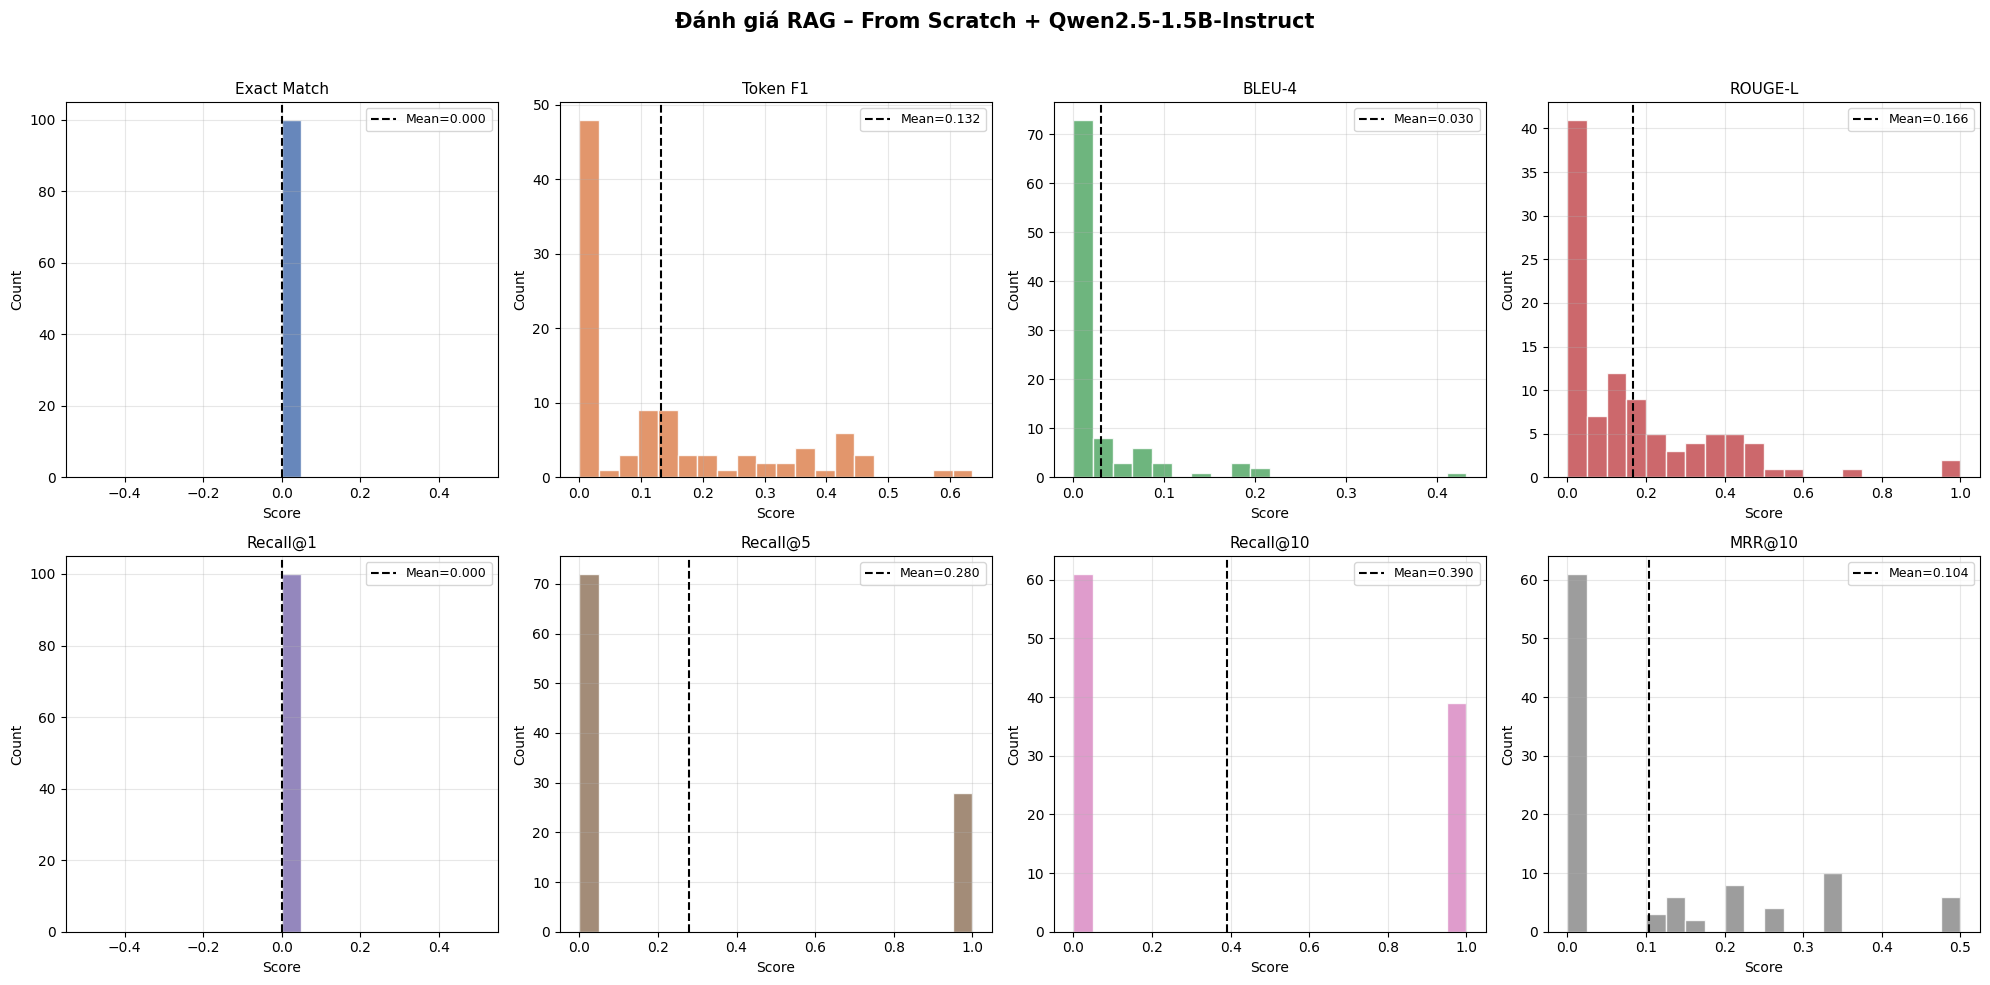

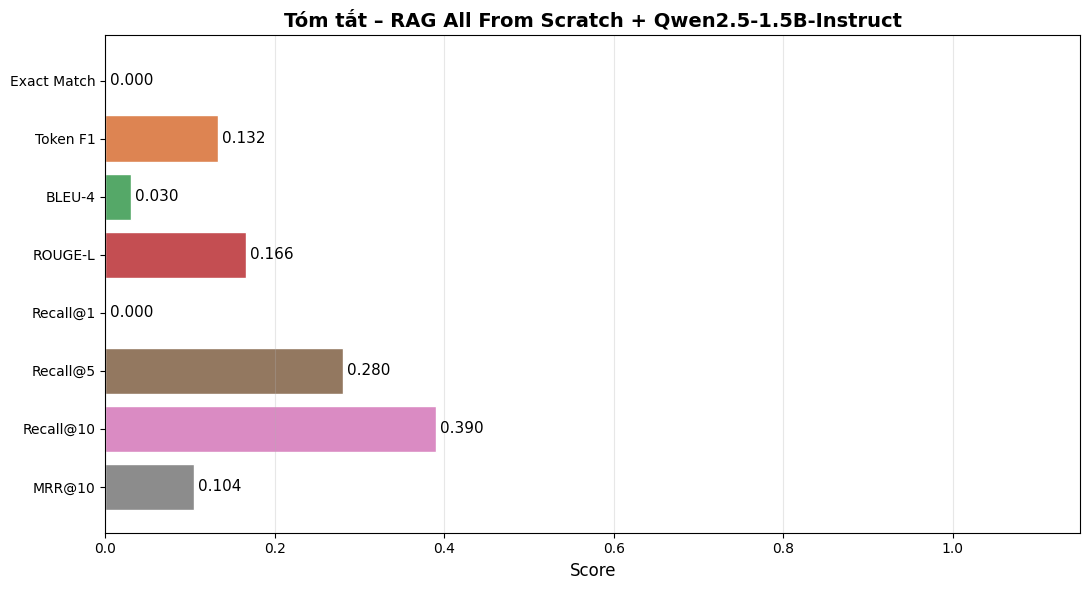

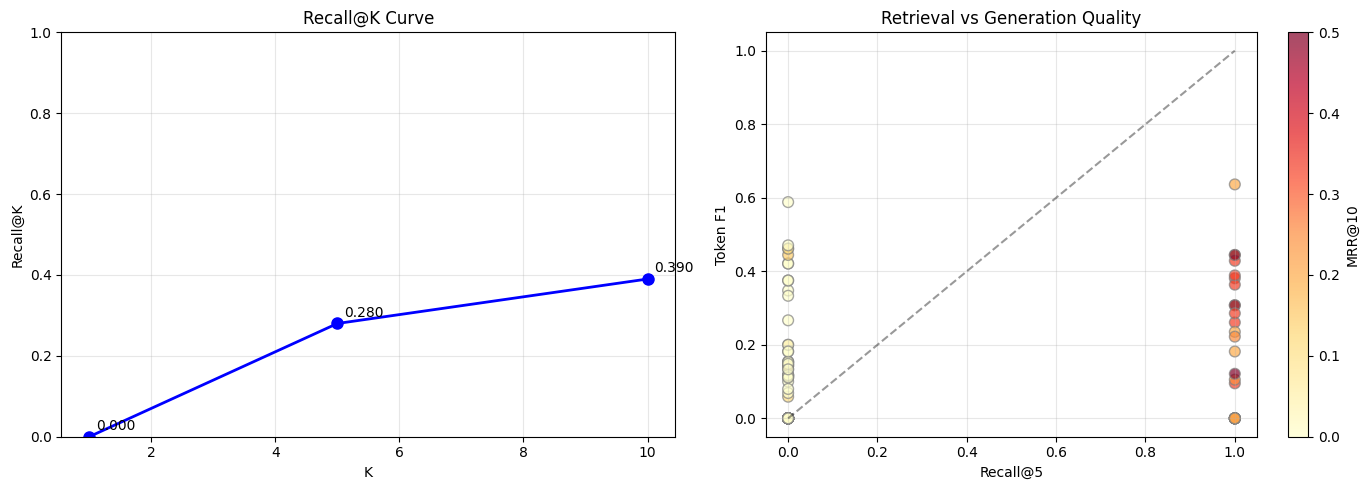

✅ Đã lưu tất cả biểu đồ!


In [19]:
# ── Visualize ──
metric_names  = ['em', 'f1', 'bleu', 'rouge_l', 'recall_1', 'recall_5', 'recall_10', 'mrr_10']
metric_labels = ['Exact Match','Token F1','BLEU-4','ROUGE-L',
                 'Recall@1','Recall@5','Recall@10','MRR@10']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52',
          '#8172B2','#937860','#DA8BC3','#8C8C8C']

# ── 1. Distribution histograms ──
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Đánh giá RAG – From Scratch + Qwen2.5-1.5B-Instruct',
             fontsize=15, fontweight='bold')
for ax, col, label, color in zip(axes.flat, metric_names, metric_labels, colors):
    vals = df[col].values
    ax.hist(vals, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean={vals.mean():.3f}')
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Score'); ax.set_ylabel('Count')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('evaluation_metrics_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Summary bar chart ──
fig, ax = plt.subplots(figsize=(11, 6))
vals = [mavg[k] for k in metric_names]
bars = ax.barh(metric_labels[::-1], vals[::-1], color=colors[::-1], edgecolor='white')
for bar, v in zip(bars, vals[::-1]):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=11)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Score', fontsize=12)
ax.set_title('Tóm tắt – RAG All From Scratch + Qwen2.5-1.5B-Instruct',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('evaluation_summary_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Retrieval analysis ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Recall curve
recall_vals = [mavg.get(f'recall_{k}', 0) for k in [1, 5, 10]]
axes[0].plot([1, 5, 10], recall_vals, 'bo-', linewidth=2, markersize=8)
for x, y in zip([1, 5, 10], recall_vals):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(5, 5))
axes[0].set_xlabel('K'); axes[0].set_ylabel('Recall@K')
axes[0].set_title('Recall@K Curve', fontsize=12)
axes[0].grid(True, alpha=0.3); axes[0].set_ylim(0, 1)

# F1 vs Recall@5
sc = axes[1].scatter(df['recall_5'], df['f1'], c=df['mrr_10'],
                      cmap='YlOrRd', alpha=0.7, edgecolors='grey', s=60)
plt.colorbar(sc, ax=axes[1], label='MRR@10')
axes[1].set_xlabel('Recall@5'); axes[1].set_ylabel('Token F1')
axes[1].set_title('Retrieval vs Generation Quality')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('retrieval_analysis_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Đã lưu tất cả biểu đồ!')

## 🖥️ Demo Tương Tác

In [20]:
def interactive_demo():
    print('='*65)
    print('🤖 RAG ĐA NGÔN NGỮ – ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct')
    print('   Hỏi bằng tiếng Việt → Trả lời bằng tiếng Việt')
    print(f'   Dữ liệu: SQuAD Wikipedia ({len(corpus_docs):,} passages)')
    print('   Gõ "thoat" để thoát')
    print('='*65)
    while True:
        print()
        q = input('❓ Câu hỏi (VI): ').strip()
        if q.lower() in ['thoat', 'quit', 'exit', 'q']:
            print('👋 Thoát.'); break
        if not q: continue
        print('⏳ Đang xử lý...')
        r = rag_pipeline(q, verbose=False)
        t = r['timings']
        print('─'*55)
        print(f'🔀 EN query : {r["query_en"]}')
        print(f'💬 EN answer: {r["answer_en"]}')
        print(f'✅ VI answer: {r["answer_vi"]}')
        print(f'\n📄 Top context:')
        for i, ctx in enumerate(r['contexts'][:2], 1):
            print(f'   [{i}] {ctx[:110]}...')
        print(f'\n⏱️  Total:{t["total"]:.2f}s '
              f'(Retrieval:{t["retrieval"]:.2f}s, '
              f'Rerank:{t["reranking"]:.2f}s, '
              f'Gemma:{t["generation"]:.2f}s)')
        print('─'*55)

interactive_demo()

🤖 RAG ĐA NGÔN NGỮ – ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct
   Hỏi bằng tiếng Việt → Trả lời bằng tiếng Việt
   Dữ liệu: SQuAD Wikipedia (20,958 passages)
   Gõ "thoat" để thoát

❓ Câu hỏi (VI): ngày giáng sinh là ngày bao nhiêu
⏳ Đang xử lý...


Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


───────────────────────────────────────────────────────
🔀 EN query : Christmas Day is what day it is.
💬 EN answer: December 25.
✅ VI answer: Ngày tháng 12

📄 Top context:
   [1] After several weeks of rumors, which started around January 11, 2013, Dell announced on February 5, 2013 that ...
   [2] Balansiyya had a rebirth of sorts with the beginning of the Taifa of Valencia kingdom in the 11th century. The...

⏱️  Total:1.49s (Retrieval:0.12s, Rerank:0.05s, Gemma:1.20s)
───────────────────────────────────────────────────────

❓ Câu hỏi (VI): thoat
👋 Thoát.


## 📋 Tổng Kết

In [21]:
summary = {
    'system': 'RAG Đa ngôn ngữ – All From Scratch + Qwen2.5-1.5B-Instruct',
    'improvements_over_v1': {
        'BPE corpus'     : '400K dòng (tăng từ 200K)',
        'BPE merges'     : '10000 (tăng từ 8000)',
        'BiEncoder arch' : 'd_model=384, n_layers=6 (tăng từ 256/4)',
        'CE arch'        : 'd_model=384, n_layers=6 (tăng từ 256/4)',
        'Corpus'         : f'SQuAD train {len(corpus_docs):,} docs (tăng từ 500)',
        'Generation'     : 'Qwen2.5-1.5B-Instruct local (thay Gemini API)',
        'FAISS'          : 'IVFFlat index (nhanh hơn FlatIP trên corpus lớn)',
        'Metrics'        : '+ Recall@1, MRR@10',
    },
    'modules': {
        'BPE_tokenizer': {
            'vocab_size' : bpe_tok.vocab_size,
            'merges'     : len(bpe_tok.merges),
            'train_data' : 'WikiText-103 400K dòng',
        },
        'Bi_Encoder': {
            'arch'       : f'd_model={D_MODEL}, n_layers={N_LAYERS}, n_head={N_HEAD}',
            'params_M'   : round(bi_encoder.n_params()/1e6, 1),
            'loss'       : 'InfoNCE, temperature=0.05',
            'train_data' : 'MS MARCO 500K pairs',
        },
        'Cross_Encoder': {
            'arch'       : f'd_model={D_MODEL}, n_layers={N_LAYERS}, n_head={N_HEAD}',
            'params_M'   : round(cross_encoder.n_params()/1e6, 1),
            'loss'       : 'BCE',
            'train_data' : 'MS MARCO 200K pairs',
        },
        'BM25'      : {'k1': 1.5, 'b': 0.75, 'from_scratch': True},
        'Generation': {'model': 'Qwen/Qwen2.5-1.5B-Instruct', 'local': True},
        'Translation': {
            'vi_en': 'Helsinki-NLP/opus-mt-vi-en',
            'en_vi': 'Helsinki-NLP/opus-mt-en-vi',
        },
    },
    'corpus'        : f'SQuAD v1.1 train {len(corpus_docs):,} docs, {len(chunks):,} chunks',
    'eval_samples'  : n,
    'final_metrics' : {k: round(v, 4) for k, v in mavg.items()},
}

with open('rag_summary_v2.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('='*65)
print('TỔNG KẾT – RAG V2 (ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct)')
print('='*65)
print()
print('📦 MODULES:')
print(f'  BPE Tokenizer  : {bpe_tok.vocab_size:,} tokens, {len(bpe_tok.merges):,} merges')
print(f'  Bi-Encoder     : {bi_encoder.n_params()/1e6:.1f}M params, d={D_MODEL}, L={N_LAYERS}')
print(f'  Cross-Encoder  : {cross_encoder.n_params()/1e6:.1f}M params, d={D_MODEL}, L={N_LAYERS}')
print(f'  BM25           : from scratch, k1=1.5, b=0.75')
print(f'  Generation     : Qwen/Qwen2.5-1.5B-Instruct (local)')
print(f'  Translation    : Helsinki Marian MT (Vi↔En)')
print()
print(f'📚 CORPUS: {len(corpus_docs):,} docs → {len(chunks):,} chunks')
print()
print('📊 KẾT QUẢ ĐÁNH GIÁ:')
for k, v in mavg.items():
    print(f'  {k:<15}: {v:.4f}')
print()
print('📁 Files saved:')
for f in ['bpe_tokenizer_v2.json', 'bi_encoder_v2.pt', 'cross_encoder_v2.pt',
          'evaluation_results_v2.csv', 'rag_summary_v2.json',
          'evaluation_metrics_v2.png', 'evaluation_summary_v2.png',
          'retrieval_analysis_v2.png']:
    exists = '✓' if os.path.exists(f) else '○'
    print(f'  {exists} {f}')
print('='*65)

TỔNG KẾT – RAG V2 (ALL FROM SCRATCH + Qwen2.5-1.5B-Instruct)

📦 MODULES:
  BPE Tokenizer  : 10,041 tokens, 10,000 merges
  Bi-Encoder     : 14.5M params, d=384, L=6
  Cross-Encoder  : 14.6M params, d=384, L=6
  BM25           : from scratch, k1=1.5, b=0.75
  Generation     : Qwen/Qwen2.5-1.5B-Instruct (local)
  Translation    : Helsinki Marian MT (Vi↔En)

📚 CORPUS: 20,958 docs → 25,385 chunks

📊 KẾT QUẢ ĐÁNH GIÁ:
  em             : 0.0000
  f1             : 0.1325
  bleu           : 0.0299
  rouge_l        : 0.1656
  recall_1       : 0.0000
  recall_5       : 0.2800
  recall_10      : 0.3900
  mrr_10         : 0.1043

📁 Files saved:
  ✓ bpe_tokenizer_v2.json
  ✓ bi_encoder_v2.pt
  ✓ cross_encoder_v2.pt
  ✓ evaluation_results_v2.csv
  ✓ rag_summary_v2.json
  ✓ evaluation_metrics_v2.png
  ✓ evaluation_summary_v2.png
  ✓ retrieval_analysis_v2.png
